In [1]:
import datetime
import json
import pickle
from pathlib import Path

import cv2
from tqdm import tqdm
from insightface.app import FaceAnalysis
import onnxruntime as ort

BASE_DIR = Path("/app")
TESTSET_PATH = BASE_DIR / "testsets/random_testset.json"
OUTPUT_ROOT = BASE_DIR / "image_outputs"
# Define path for reference database JSON
REF_DB_JSON_PATH = BASE_DIR / "notebooks/data/reference_embeddings.json"

CLASSIFIER_NAME = "insightface"
DET_SIZE = (640, 640)
THRESHOLD = 0.3  # Cosine similarity threshold for identification (higher = stricter)

print(f"Testset: {TESTSET_PATH}")


/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Testset: /app/testsets/random_testset.json


In [2]:
def init_insightface():
    """Initialize InsightFace with both detection AND recognition modules"""
    available = ort.get_available_providers()
    prefer_cuda = "CUDAExecutionProvider" in available
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if prefer_cuda else ["CPUExecutionProvider"]
    ctx_id = 0 if prefer_cuda else -1
    try:
        # Enable both detection and recognition for full face identification
        app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
        app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
        print(f"InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
        print(f"Enabled modules: detection + recognition for face identification")
        return app
    except Exception as e:
        if prefer_cuda:
            print(f"GPU init failed ({e}); retrying on CPU only.")
            providers = ["CPUExecutionProvider"]
            ctx_id = -1
            app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
            app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
            print(f"InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
            return app
        raise

app = init_insightface()

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

In [3]:
import numpy as np

# Load and normalize references metadata (new schema only)
REFERENCES_PATH = BASE_DIR / "data/references.json"
with open(REFERENCES_PATH, "r", encoding="utf-8") as f:
    raw_references = json.load(f)


def parse_references_metadata(raw):
    """
    Parse references metadata using the new schema.
    
    Expected structure: list of objects with:
    - "reference_images": [{"image_path": str}]
    
    Returns a normalized list of objects:
    [{ "name": str, "paths": List[str], "embeddings": [] }]
    """
    if not isinstance(raw, list):
        raise ValueError("references.json must be a list of objects")

    refs = []
    for obj in raw:
        if not isinstance(obj, dict):
            continue
        name = obj.get("name")
        if not name:
            continue

        # Extract image paths from reference_images field
        paths = []
        reference_images = obj.get("reference_images")
        if reference_images:
            for img_obj in reference_images:
                if isinstance(img_obj, dict) and "image_path" in img_obj:
                    p = img_obj["image_path"]
                    if p:
                        paths.append(str(BASE_DIR / p) if not str(p).startswith("/") else str(p))
        
        # Deduplicate
        paths = list(dict.fromkeys(paths))
        
        if paths:  # Only add if we have at least one path
            refs.append({
                "name": name,
                "paths": paths,
                "embeddings": []
            })

    return refs

references = parse_references_metadata(raw_references)
print(f"Loaded and normalized {len(references)} references from metadata")

# reference_db will be loaded or built in the next cell
reference_db = None


Loaded and normalized 4 references from metadata


In [4]:
references

[{'name': 'Hugh Jackman',
  'paths': ['/app/Images/references/HughJackman.jpg'],
  'embeddings': []},
 {'name': 'Donald Trump',
  'paths': ['/app/Images/references/DonaldTrump.jpg'],
  'embeddings': []},
 {'name': 'Giorgia Meloni',
  'paths': ['/app/Images/references/GiorgiaMeloni.jpg'],
  'embeddings': []},
 {'name': 'Lionel Messi',
  'paths': ['/app/Images/references/LionnelMessi.png'],
  'embeddings': []}]

In [5]:
def build_reference_db(references, app):
    """Build reference embeddings from new references metadata using InsightFace.
    Computes embeddings from image paths in references file.
    Returns a list of reference objects:
    [{
        "name": str,
        "embeddings": [
          {
            "embedding": np.ndarray,
            "main_image_path": str,
            "face_image_path": str
          }
        ]
    }]
    """
    # Create folder for extracted face images
    face_crops_dir = BASE_DIR / "Images/references/References_cropped"
    face_crops_dir.mkdir(parents=True, exist_ok=True)
    
    ref_db_list = []
    for ref in references:
        name = ref.get("name")
        paths = ref.get("paths", [])

        # Compute embeddings from image paths
        emb_objects = []
        for p in paths:
            ref_path = Path(p)
            if not ref_path.exists():
                print(f"⚠️  Missing reference image for {name}: {ref_path}")
                continue
            img = cv2.imread(str(ref_path))
            if img is None:
                print(f"⚠️  Unable to load reference image for {name}: {ref_path}")
                continue
            faces = app.get(img)
            if not faces:
                print(f"⚠️  No face detected in reference image for {name}: {ref_path}")
                continue
            # Use the largest face as reference
            face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
            embedding = face.normed_embedding
            
            # Extract and save face crop
            x1, y1, x2, y2 = [int(v) for v in face.bbox]
            face_crop = img[y1:y2, x1:x2]
            
            # Generate unique filename for face crop
            face_filename = f"{name.replace(' ', '_')}_{ref_path.stem}.jpg"
            face_crop_path = face_crops_dir / face_filename
            cv2.imwrite(str(face_crop_path), face_crop)
            
            emb_objects.append({
                "embedding": embedding,
                "main_image_path": str(ref_path),
                "face_image_path": str(face_crop_path)
            })

        if not emb_objects:
            print(f"⚠️  No embeddings available for {name}; skipping")
            continue

        ref_db_list.append({
            "name": name,
            "embeddings": emb_objects
        })
        print(f"✓ Loaded reference for {name} (embeddings: {len(emb_objects)})")
    
    print(f"\n✓ Reference database built with {len(ref_db_list)} identities")
    print(f"✓ Face crops saved to {face_crops_dir}")
    return ref_db_list


In [6]:
def save_reference_db(ref_db_list, filepath_json):
    """
    Save reference database to JSON.
    JSON format: list of reference objects, each with an `embeddings` array of objects.
    Example:
    [
      {
        "name": "Reference Name",
        "embeddings": [
          {
            "embedding": [..floats..],
            "main_image_path": "/path/to/main/image.jpg",
            "face_image_path": "/path/to/face/image.jpg"
          }
        ]
      }
    ]
    """
    filepath_json.parent.mkdir(parents=True, exist_ok=True)
    
    # JSON: convert embeddings to lists
    ref_db_json_list = []
    for ref in ref_db_list:
        embeddings_array = []
        for emb_obj in ref.get("embeddings", []):
            emb = emb_obj.get("embedding")
            # Convert numpy array to list for JSON
            if hasattr(emb, "tolist"):
                emb_list = emb.tolist()
            else:
                emb_list = list(emb) if emb is not None else []
            embeddings_array.append({
                "embedding": emb_list,
                "main_image_path": emb_obj.get("main_image_path"),
                "face_image_path": emb_obj.get("face_image_path")
            })
        ref_db_json_list.append({
            "name": ref.get("name"),
            "embeddings": embeddings_array
        })
    
    with open(filepath_json, "w", encoding="utf-8") as f:
        json.dump(ref_db_json_list, f, indent=2)
    print(f"✓ Saved reference database to {filepath_json}")


def load_reference_db(filepath_json):
    """
    Load reference database from JSON.
    Expects a list of reference objects with embeddings arrays.
    Returns a list with embeddings as numpy arrays.
    """
    with open(filepath_json, "r", encoding="utf-8") as f:
        ref_db_json = json.load(f)
    
    if not isinstance(ref_db_json, list):
        raise ValueError("Reference embeddings JSON must be a list of references")

    ref_db_list = []
    for ref in ref_db_json:
        name = ref.get("name")
        embeddings_list = ref.get("embeddings", [])
        emb_objects = []
        for emb_item in embeddings_list:
            if isinstance(emb_item, dict) and "embedding" in emb_item:
                emb_objects.append({
                    "embedding": np.array(emb_item["embedding"], dtype=np.float32),
                    "main_image_path": emb_item.get("main_image_path"),
                    "face_image_path": emb_item.get("face_image_path")
                })
        if name and emb_objects:
            ref_db_list.append({
                "name": name,
                "embeddings": emb_objects
            })
    print(f"✓ Loaded reference database from {filepath_json}")
    print(f"  Loaded {len(ref_db_list)} identities")
    return ref_db_list


# Load or build reference database with error handling for old format
if REF_DB_JSON_PATH.exists():
    try:
        reference_db = load_reference_db(REF_DB_JSON_PATH)
    except (ValueError, KeyError) as e:
        print(f"⚠️  Existing reference DB has wrong format: {e}")
        print("   Deleting and rebuilding from metadata...")
        REF_DB_JSON_PATH.unlink()  # Delete the old file
        reference_db = build_reference_db(references, app)
        save_reference_db(reference_db, REF_DB_JSON_PATH)
else:
    print("Reference DB file not found; building from metadata...")
    reference_db = build_reference_db(references, app)
    save_reference_db(reference_db, REF_DB_JSON_PATH)


✓ Loaded reference database from /app/notebooks/data/reference_embeddings.json
  Loaded 4 identities


In [7]:
with open(TESTSET_PATH, "r", encoding="utf-8") as f:
    test_items = json.load(f)

print(f"Loaded {len(test_items)} images from test set")

Loaded 54 images from test set


In [8]:
# ===== VERIFY REFERENCE DATABASE =====
print("\n=== Verifying Reference Database ===\n")

if reference_db:
    print(f"✓ Reference database loaded successfully")
    print(f"  Total identities: {len(reference_db)}")
    print(f"\n  Sample identity: {reference_db[0]['name']}")
    sample_embedding = reference_db[0]["embeddings"][0]["embedding"]
    print(f"  Embedding type: {type(sample_embedding)}")
    print(f"  Embedding shape: {sample_embedding.shape}")
    print(f"  Embedding dtype: {sample_embedding.dtype}")
    print(f"  Main image path: {reference_db[0]['embeddings'][0]['main_image_path']}")
    print(f"  Face image path: {reference_db[0]['embeddings'][0]['face_image_path']}")
else:
    print("⚠️  Reference database is empty")

print("\n✓ Reference database ready for model inference!")



=== Verifying Reference Database ===

✓ Reference database loaded successfully
  Total identities: 4

  Sample identity: Hugh Jackman
  Embedding type: <class 'numpy.ndarray'>
  Embedding shape: (512,)
  Embedding dtype: float32
  Main image path: /app/Images/references/HughJackman.jpg
  Face image path: /app/Images/references/References_cropped/Hugh_Jackman_HughJackman.jpg

✓ Reference database ready for model inference!


In [9]:
def identify_face(embedding, threshold=None):
    """
    Identify a face by comparing its embedding to reference database using cosine similarity.
    Supports multiple embeddings per celebrity; uses max similarity across a celebrity's embeddings.
    
    Args:
        embedding: Face embedding from InsightFace
        threshold: Cosine similarity threshold (higher = more strict). If None, uses global THRESHOLD
    
    Returns:
        tuple: (name, similarity) or (None, None) if no match
    """
    if threshold is None:
        threshold = THRESHOLD
    if not reference_db:
        return None, None
    
    best_match = None
    best_similarity = -1.0
    
    for celeb in reference_db:
        name = celeb.get("name")
        emb_list = celeb.get("embeddings", [])
        # Max similarity across all embeddings for this celebrity
        max_sim = -1.0
        for emb_obj in emb_list:
            ref_emb = emb_obj.get("embedding")
            if ref_emb is None:
                continue
            sim = float(np.dot(embedding, ref_emb))
            if sim > max_sim:
                max_sim = sim
        if max_sim > best_similarity:
            best_similarity = max_sim
            best_match = name
    
    # Return match if above threshold
    if best_similarity >= threshold:
        return best_match, best_similarity
    else:
        return None, None


def get_all_similarities(embedding):
    """
    Get cosine similarities to ALL reference faces.
    Computes the max similarity per celebrity across all available embeddings.
    
    Args:
        embedding: Face embedding from InsightFace
    
    Returns:
        dict: {name: similarity} sorted by similarity (highest first)
    """
    if not reference_db:
        return {}
    
    similarities = {}
    for celeb in reference_db:
        name = celeb.get("name")
        emb_list = celeb.get("embeddings", [])
        max_sim = -1.0
        for emb_obj in emb_list:
            ref_emb = emb_obj.get("embedding")
            if ref_emb is None:
                continue
            sim = float(np.dot(embedding, ref_emb))
            if sim > max_sim:
                max_sim = sim
        if name is not None and max_sim >= -1.0:
            similarities[name] = max_sim
    
    # Sort by similarity (highest first)
    return dict(sorted(similarities.items(), key=lambda x: x[1], reverse=True))

In [ ]:
import random

def add_embedding_to_reference_db(reference_db, name, embedding, main_image_path=None, face_image_path=None):
    """Append a new embedding to an identity in reference_db (or create it)."""
    if reference_db is None:
        raise ValueError("reference_db is not loaded")
    if embedding is None:
        raise ValueError("embedding is required")

    emb_obj = {
        "embedding": np.array(embedding, dtype=np.float32),
        "main_image_path": main_image_path,
        "face_image_path": face_image_path
    }

    for ref in reference_db:
        if ref.get("name") == name:
            ref.setdefault("embeddings", []).append(emb_obj)
            return ref

    # If identity does not exist, create it
    reference_db.append({"name": name, "embeddings": [emb_obj]})
    return reference_db[-1]

def random_acceptance_criteria(candidate, rng=None, p_accept=0.5):
    """Randomly decide whether a candidate item should be added (placeholder criteria)."""
    rng = rng or random
    return rng.random() < p_accept

def sample_test_items_for_reference_update(test_items, criteria_fn, seed=1234, max_samples=None, p_accept=0.5):
    """Select test items for possible reference updates using a seeded RNG and criteria_fn."""
    rng = random.Random(seed)
    selected = []
    for item in test_items:
        if criteria_fn(item, rng=rng, p_accept=p_accept):
            selected.append(item)
            if max_samples is not None and len(selected) >= max_samples:
                break
    return selected

def min_distance_to_reference(embedding, reference_db):
    """Compute min cosine distance to each identity (supports multiple embeddings per person)."""
    if embedding is None or reference_db is None:
        return None, None, {}

    distances = {}
    for celeb in reference_db:
        name = celeb.get("name")
        emb_list = celeb.get("embeddings", [])
        if not emb_list:
            continue
        dist_values = []
        for emb_obj in emb_list:
            ref_emb = emb_obj.get("embedding")
            if ref_emb is None:
                continue
            dist_values.append(1 - float(np.dot(embedding, ref_emb)))
        if not dist_values:
            continue
        distances[name] = min(dist_values)

    if not distances:
        return None, None, {}

    best_name = min(distances, key=distances.get)
    return best_name, distances[best_name], distances

In [10]:
# ===== USE LOADED DATABASE FOR MODEL INFERENCE =====
print("\n=== Inference Example using Loaded Reference Database ===\n")

def inference_with_ref_db(image_path, ref_db, threshold=None):
    """Run inference on an image using cosine similarity against a reference DB."""
    if threshold is None:
        threshold = THRESHOLD
    img = cv2.imread(str(image_path))
    if img is None:
        return []
    
    faces = app.get(img)
    results = []
    
    for face in faces:
        embedding = face.normed_embedding
        all_similarities = get_all_similarities(embedding)
        
        # Get best match from pre-computed similarities (already sorted)
        if all_similarities:
            best_name, best_similarity = next(iter(all_similarities.items()))
            is_identified = best_similarity >= threshold
        else:
            best_name, best_similarity = None, 0.0
            is_identified = False
        
        top_matches = list(all_similarities.items())[:3]
        
        result = {
            "bbox": face.bbox.tolist(),
            "identified": is_identified,
            "name": best_name if is_identified else "Unknown",
            "confidence": float(best_similarity),
            "similarity": float(best_similarity),
            "all_similarities": {k: float(v) for k, v in top_matches}
        }
        results.append(result)
    
    return results


if test_items:
    test_img_path = BASE_DIR / test_items[0].get("path", "")
    inference_results = inference_with_ref_db(test_img_path, reference_db)
    print(f"Testing inference on: {test_items[0]['path']}")
    inference_results = inference_with_ref_db(test_img_path, reference_db, threshold=0.8)
    
    print(f"Found {len(inference_results)} faces:")
    for i, result in enumerate(inference_results):
        print(f"\n  Face {i+1}:")
        print(f"    Name: {result['name']}")
        print(f"    Identified: {result['identified']}")
        print(f"    Similarity: {result['similarity']:.3f}")
        print(f"    Top 3 matches: {result['all_similarities']}")
else:
    print(f"⚠️  Test image not found: {test_img_path}")





=== Inference Example using Loaded Reference Database ===



/opt/venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Testing inference on: Images/random Testset/Donald Trump/01-00353911000011x.jpg
Found 1 faces:

  Face 1:
    Name: Unknown
    Identified: False
    Similarity: 0.481
    Top 3 matches: {'Donald Trump': 0.4814303517341614, 'Hugh Jackman': -0.0507471039891243, 'Giorgia Meloni': -0.06282265484333038}


In [11]:
import csv

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = OUTPUT_ROOT / f"{timestamp}_{CLASSIFIER_NAME}_only-faceDetector_det{DET_SIZE[0]}x{DET_SIZE[1]}"
output_dir.mkdir(parents=True, exist_ok=True)

# ===== SINGLE EFFICIENT PASS: Process all images once and collect all data =====
# Data structures to collect in single pass
failed = []
stats = {
    "total_images": 0,
    "images_with_faces": 0,
    "total_faces": 0,
    "identified_faces": 0,
    "unknown_faces": 0,
    "by_identity": {}
}

predictions_list = []  # For multilabel metrics
ground_truth_list = []  # For multilabel metrics
all_identity_names = sorted([c["name"] for c in reference_db])

# Setup CSV writer
csv_path = output_dir / "detailed_similarities.csv"
fieldnames = ["image_name", "face_id", "best_match", "best_similarity"] + [f"{name}_similarity" for name in all_identity_names]
csv_file = open(csv_path, "w", newline="", encoding="utf-8")
csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
csv_writer.writeheader()

face_count_global = 0

print("Processing all images in single pass...")

for item in tqdm(test_items, desc="Processing images"):
    img_path = BASE_DIR / item.get("path", "")
    if not img_path.exists():
        failed.append({"path": str(img_path), "reason": "missing file"})
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        failed.append({"path": str(img_path), "reason": "unable to load"})
        continue

    # ===== SINGLE DETECTION/IDENTIFICATION PASS =====
    faces = app.get(img)
    annotated = img.copy()
    
    stats["total_images"] += 1
    
    # For metrics collection - use "labels" field from test set (not "identities")
    ground_truth = set(item.get("labels", []))
    predicted_identities = set()

    if not faces:
        cv2.putText(annotated, "No faces detected", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    else:
        stats["images_with_faces"] += 1
        stats["total_faces"] += len(faces)
        
        # First pass: identify all faces and count recognized ones
        face_identifications = []
        legend_mapping = {}
        
        for face_idx, face in enumerate(faces):
            embedding = face.normed_embedding
            all_similarities = get_all_similarities(embedding)
            
            # Get best match from pre-computed similarities (already sorted)
            if all_similarities:
                name, best_similarity = next(iter(all_similarities.items()))
                if best_similarity < THRESHOLD:
                    name = None
            else:
                name, best_similarity = None, None
            
            face_identifications.append({
                'face_idx': face_idx,
                'face': face,
                'name': name,
                'best_similarity': best_similarity,
                'all_similarities': all_similarities
            })
            
            if name:
                legend_mapping[face_idx + 1] = name
        
        # Count total identified in this image
        total_identified = sum(1 for f in face_identifications if f['name'] is not None)
        
        # Second pass: draw annotations
        for face_data in face_identifications:
            face_count_global += 1
            face = face_data['face']
            name = face_data['name']
            best_similarity = face_data['best_similarity']
            all_similarities = face_data['all_similarities']
            
            x1, y1, x2, y2 = [int(v) for v in face.bbox]
            det_score = getattr(face, "det_score", None)
            
            # Update predictions for metrics
            if name:
                predicted_identities.add(name)
                stats["identified_faces"] += 1
                if name not in stats["by_identity"]:
                    stats["by_identity"][name] = {"count": 0, "avg_similarity": []}
                stats["by_identity"][name]["count"] += 1
                stats["by_identity"][name]["avg_similarity"].append(best_similarity)
            else:
                stats["unknown_faces"] += 1
            
            # Build label with conditional display
            color = (0, 255, 0) if name else (0, 165, 255)  # Green for identified, Orange for unknown
            
            # LABEL LOGIC:
            # - If only ONE person total in image AND identified: show complete label
            # - If unknown: show all scores without name label
            # - Otherwise: show number with score
            lines = []
            
            if name:
                if len(faces) == 1:
                    # Only one face in image and it's identified: show complete label
                    lines.append(f"[ID] {name}")
                    lines.append(f"Similarity: {best_similarity:.2f}")
                else:
                    # Multiple faces: show number, name and score
                    number = face_data['face_idx'] + 1
                    lines.append(f"{number}. {name}")
                    lines.append(f"Score: {best_similarity:.2f}")
                    
                    # Add all similarity scores with numbers
                    for idx, (ref_name, sim) in enumerate(all_similarities.items(), 1):
                        marker = "*" if ref_name == name else " "
                        lines.append(f"  {marker} {idx}. {sim:.2f}")
            else:
                # Unknown face: show all similarity scores but no "UNKNOWN" text (orange box is enough)
                if len(faces) == 1:
                    # Single unknown face: show scores only
                    for idx, (ref_name, sim) in enumerate(all_similarities.items(), 1):
                        lines.append(f"  {idx}. {sim:.2f}")
                else:
                    # Multiple faces with unknown: show number and scores (no "UNKNOWN" text)
                    number = face_data['face_idx'] + 1
                    lines.append(f"{number}.")
                    # Add all similarity scores
                    for idx, (ref_name, sim) in enumerate(all_similarities.items(), 1):
                        lines.append(f"  {idx}. {sim:.2f}")
            
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            
            # Draw multi-line label only if we have lines to show
            if lines:
                y_offset = max(y1 - 10, 10)
                for line in lines:
                    cv2.putText(annotated, line, (x1, y_offset), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                    y_offset += 16
            
            # Write CSV row
            csv_row = {
                "image_name": img_path.name,
                "face_id": face_count_global,
                "best_match": name or "Unknown",
                "best_similarity": best_similarity if best_similarity is not None else "N/A"
            }
            for ref_name, sim in all_similarities.items():
                csv_row[f"{ref_name}_similarity"] = f"{sim:.4f}"
            csv_writer.writerow(csv_row)
        
        # Add legend to bottom of image if there are multiple identified people
        if len(faces) > 1 and len(legend_mapping) > 0:
            # Draw legend background
            legend_x = 10
            legend_y = annotated.shape[0] - 10 - (len(legend_mapping) * 18)
            legend_width = 250
            legend_height = len(legend_mapping) * 18 + 10
            
            cv2.rectangle(annotated, (legend_x, legend_y), 
                         (legend_x + legend_width, legend_y + legend_height),
                         (0, 0, 0), -1)  # Black background
            cv2.rectangle(annotated, (legend_x, legend_y), 
                         (legend_x + legend_width, legend_y + legend_height),
                         (255, 255, 255), 1)  # White border
            
            # Draw legend entries
            legend_text_y = legend_y + 15
            for number in sorted(legend_mapping.keys()):
                name = legend_mapping[number]
                text = f"{number}. {name}"
                cv2.putText(annotated, text, (legend_x + 5, legend_text_y),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                legend_text_y += 18

    # Save annotated image
    out_path = output_dir / img_path.name
    cv2.imwrite(str(out_path), annotated)
    
    # Collect for multilabel metrics
    if ground_truth or predicted_identities:
        predictions_list.append(list(predicted_identities))
        ground_truth_list.append(list(ground_truth))

csv_file.close()

# Compute averages for stats
for name in stats["by_identity"]:
    sims = stats["by_identity"][name]["avg_similarity"]
    stats["by_identity"][name]["avg_similarity"] = np.mean(sims)

print(f"\n✓ Single pass processing complete!")
print(f"✓ Annotated images saved to {output_dir}")
print(f"✓ CSV report saved to {csv_path}")

if failed:
    print(f"⚠️  Skipped {len(failed)} images:")
    for miss in failed[:10]:
        print(f"  - {miss}")
    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")

print(f"✓ Collected {len(predictions_list)} images for metrics evaluation")

# Print identification statistics
print("\n" + "=" * 60)
print("IDENTIFICATION STATISTICS")
print("=" * 60)
print(f"Total images processed: {stats['total_images']}")
print(f"Images with faces: {stats['images_with_faces']}")
print(f"Total faces detected: {stats['total_faces']}")
print(f"Identified faces: {stats['identified_faces']} ({stats['identified_faces']/max(stats['total_faces'],1)*100:.1f}%)")
print(f"Unknown faces: {stats['unknown_faces']} ({stats['unknown_faces']/max(stats['total_faces'],1)*100:.1f}%)")
print()
print("By Identity:")

print("-" * 60)


Processing all images in single pass...


Processing images: 100%|██████████| 54/54 [00:10<00:00,  5.10it/s]


✓ Single pass processing complete!
✓ Annotated images saved to /app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640
✓ CSV report saved to /app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/detailed_similarities.csv
✓ Collected 54 images for metrics evaluation

IDENTIFICATION STATISTICS
Total images processed: 54
Images with faces: 54
Total faces detected: 359
Identified faces: 42 (11.7%)
Unknown faces: 317 (88.3%)

By Identity:
------------------------------------------------------------


In [12]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, multilabel_confusion_matrix,
    hamming_loss, jaccard_score, roc_auc_score
)
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data was already collected in previous cell - no re-processing needed
print(f"✓ Using pre-collected data: {len(predictions_list)} images")

# Binarize labels for multilabel metrics
mlb = MultiLabelBinarizer(classes=all_identity_names)
y_true_binary = mlb.fit_transform(ground_truth_list)
y_pred_binary = mlb.transform(predictions_list)

print("\n" + "=" * 70)
print("MULTILABEL MULTICLASS CLASSIFICATION METRICS")
print("=" * 70)

# Subset Accuracy (exact match ratio)
subset_accuracy = accuracy_score(y_true_binary, y_pred_binary)
print(f"\nSubset Accuracy (Exact Match): {subset_accuracy:.4f}")

# Hamming Loss (fraction of labels that are incorrectly predicted)
h_loss = hamming_loss(y_true_binary, y_pred_binary)
print(f"Hamming Loss: {h_loss:.4f}")

# Jaccard Score (intersection / union)
j_score = jaccard_score(y_true_binary, y_pred_binary, average='samples')
print(f"Jaccard Score (samples): {j_score:.4f}")

# Per-label metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Micro-averaged):")
print("-" * 70)
precision_micro = precision_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)
recall_micro = recall_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)
f1_micro = f1_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)

print(f"Precision (micro): {precision_micro:.4f}")
print(f"Recall (micro):    {recall_micro:.4f}")
print(f"F1-Score (micro):  {f1_micro:.4f}")

# Macro-averaged metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Macro-averaged):")
print("-" * 70)
precision_macro = precision_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)
recall_macro = recall_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)
f1_macro = f1_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)

print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro):    {recall_macro:.4f}")
print(f"F1-Score (macro):  {f1_macro:.4f}")

# Weighted-average metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Weighted-average):")
print("-" * 70)
precision_weighted = precision_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-Score (weighted):  {f1_weighted:.4f}")

# Per-class detailed report
print("\n" + "=" * 70)
print("Per-Class Detailed Report:")
print("=" * 70)
class_report = classification_report(
    y_true_binary, y_pred_binary, 
    target_names=all_identity_names,
    zero_division=0
)
print(class_report)

print("=" * 70)


✓ Using pre-collected data: 54 images

MULTILABEL MULTICLASS CLASSIFICATION METRICS

Subset Accuracy (Exact Match): 0.7593
Hamming Loss: 0.0602
Jaccard Score (samples): 0.6111

----------------------------------------------------------------------
Per-Label Metrics (Micro-averaged):
----------------------------------------------------------------------
Precision (micro): 0.8571
Recall (micro):    0.8372
F1-Score (micro):  0.8471

----------------------------------------------------------------------
Per-Label Metrics (Macro-averaged):
----------------------------------------------------------------------
Precision (macro): 0.8500
Recall (macro):    0.8431
F1-Score (macro):  0.8387

----------------------------------------------------------------------
Per-Label Metrics (Weighted-average):
----------------------------------------------------------------------
Precision (weighted): 0.8837
Recall (weighted):    0.8372
F1-Score (weighted):  0.8513

Per-Class Detailed Report:
              

/opt/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['None'] will be ignored
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in samples with no true or predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


✓ Metrics visualization saved to: /app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/multilabel_multiclass_metrics.png


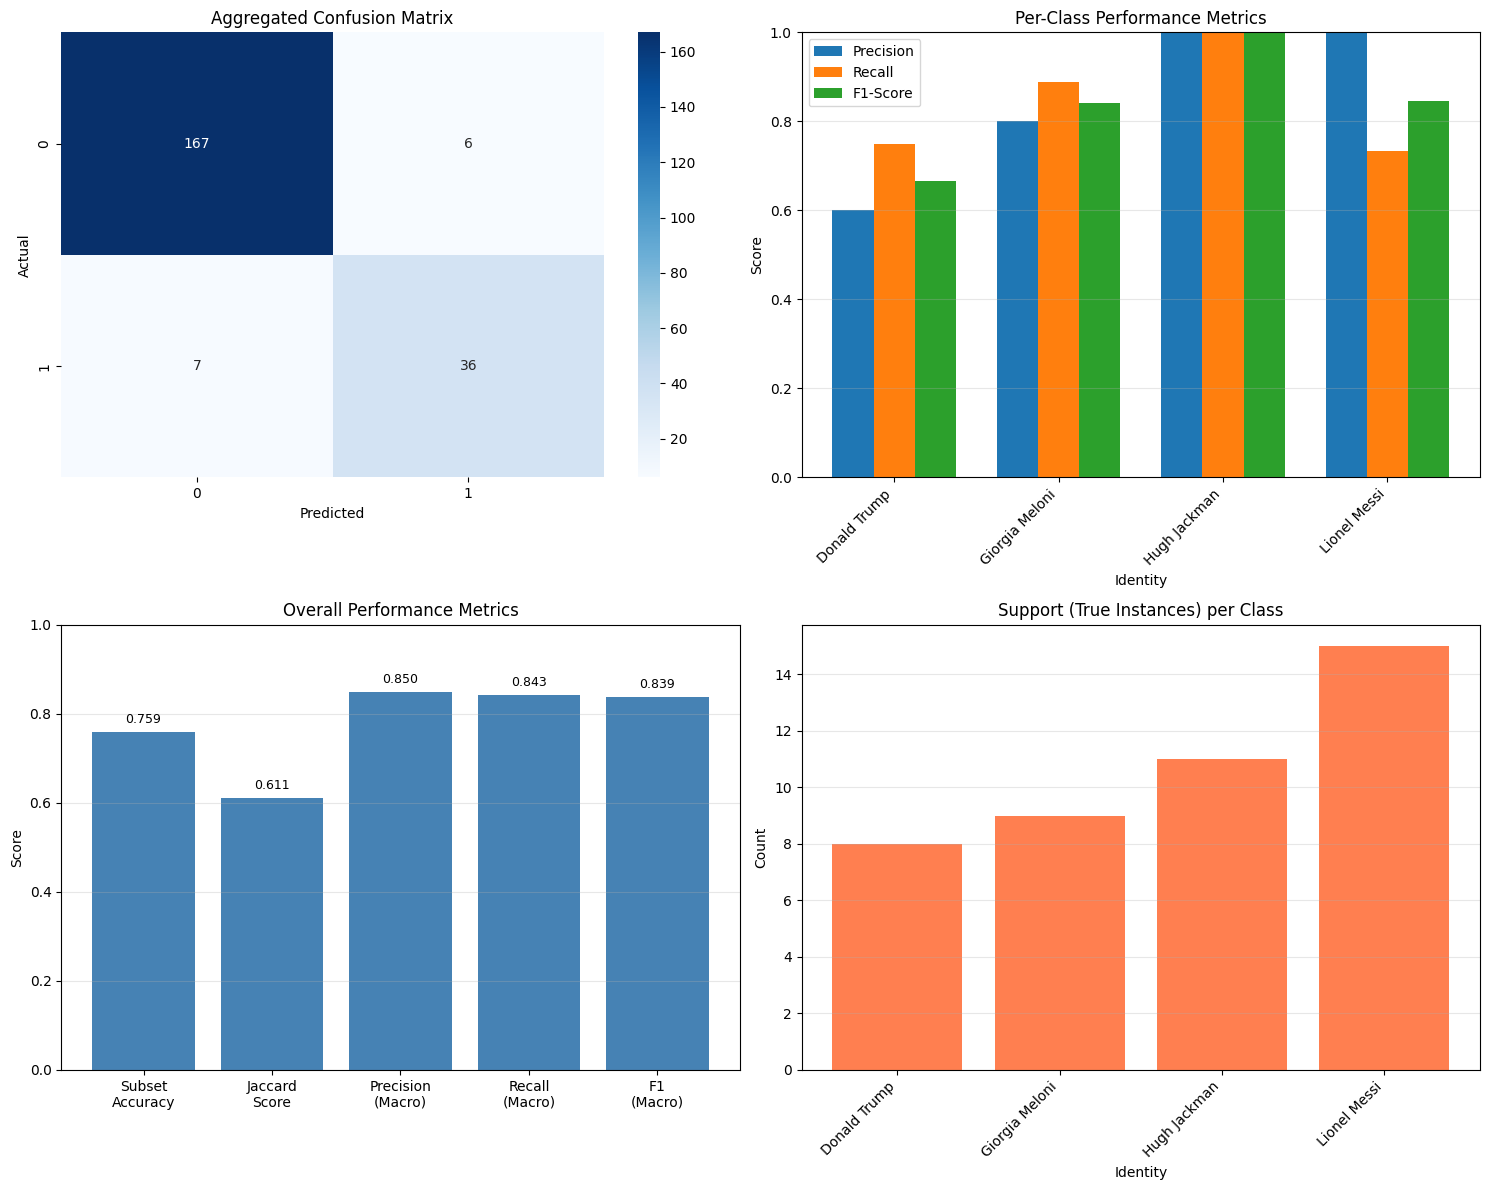

In [13]:
# Visualizations for multilabel multiclass metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix (aggregated across all labels)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Aggregated Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. Per-class metrics comparison
metrics_per_class = []
for i, name in enumerate(all_identity_names):
    prec = precision_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    rec = recall_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    f1 = f1_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    metrics_per_class.append({'name': name, 'precision': prec, 'recall': rec, 'f1': f1})

metrics_df = pd.DataFrame(metrics_per_class)
x_pos = range(len(metrics_df))
width = 0.25

axes[0, 1].bar([p - width for p in x_pos], metrics_df['precision'], width, label='Precision')
axes[0, 1].bar(x_pos, metrics_df['recall'], width, label='Recall')
axes[0, 1].bar([p + width for p in x_pos], metrics_df['f1'], width, label='F1-Score')
axes[0, 1].set_xlabel('Identity')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Per-Class Performance Metrics')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(metrics_df['name'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Summary metrics comparison
summary_metrics = {
    'Subset\nAccuracy': subset_accuracy,
    'Jaccard\nScore': j_score,
    'Precision\n(Macro)': precision_macro,
    'Recall\n(Macro)': recall_macro,
    'F1\n(Macro)': f1_macro,
}
axes[1, 0].bar(summary_metrics.keys(), summary_metrics.values(), color='steelblue')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Overall Performance Metrics')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(summary_metrics.items()):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 4. Support (number of true instances per class)
support_per_class = y_true_binary.sum(axis=0)
axes[1, 1].bar(all_identity_names, support_per_class, color='coral')
axes[1, 1].set_xlabel('Identity')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Support (True Instances) per Class')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
metrics_plot_path = output_dir / "multilabel_multiclass_metrics.png"
plt.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Metrics visualization saved to: {metrics_plot_path}")
plt.show()


In [14]:
# Save detailed metrics to CSV
metrics_summary_path = output_dir / "metrics_summary.csv"
with open(metrics_summary_path, 'w', newline='', encoding='utf-8') as f:
    f.write("Multilabel Multiclass Classification Metrics Summary\n")
    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"Threshold: {THRESHOLD}\n")
    f.write(f"Images Evaluated: {len(predictions_list)}\n")
    f.write("\n")
    
    f.write("Overall Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Subset Accuracy (Exact Match),{subset_accuracy:.4f}\n")
    f.write(f"Hamming Loss,{h_loss:.4f}\n")
    f.write(f"Jaccard Score,{j_score:.4f}\n")
    f.write("\n")
    
    f.write("Micro-averaged Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_micro:.4f}\n")
    f.write(f"Recall,{recall_micro:.4f}\n")
    f.write(f"F1-Score,{f1_micro:.4f}\n")
    f.write("\n")
    
    f.write("Macro-averaged Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_macro:.4f}\n")
    f.write(f"Recall,{recall_macro:.4f}\n")
    f.write(f"F1-Score,{f1_macro:.4f}\n")
    f.write("\n")
    
    f.write("Weighted-average Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_weighted:.4f}\n")
    f.write(f"Recall,{recall_weighted:.4f}\n")
    f.write(f"F1-Score,{f1_weighted:.4f}\n")
    f.write("\n")
    
    f.write("Per-Class Metrics\n")
    f.write("-" * 50 + "\n")
    f.write("Identity,Precision,Recall,F1-Score,Support\n")
    for i, name in enumerate(all_identity_names):
        prec = precision_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        rec = recall_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        f1 = f1_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        support = int(y_true_binary[:, i].sum())
        f.write(f"{name},{prec:.4f},{rec:.4f},{f1:.4f},{support}\n")

print(f"✓ Metrics summary saved to: {metrics_summary_path}")

# Display summary
print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"Total images with faces: {len(predictions_list)}")
print(f"Threshold used: {THRESHOLD}")
print(f"\nBest Metrics:")
print(f"  • Subset Accuracy: {subset_accuracy:.4f} (exact match on all labels)")
print(f"  • F1-Score (Macro): {f1_macro:.4f} (balanced across all classes)")
print(f"  • F1-Score (Weighted): {f1_weighted:.4f} (weighted by support)")
print(f"\nFiles generated:")
print(f"  • {output_dir.name}/multilabel_multiclass_metrics.png")
print(f"  • {output_dir.name}/metrics_summary.csv")
print(f"  • {output_dir.name}/detailed_similarities.csv")
print("=" * 70)


✓ Metrics summary saved to: /app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/metrics_summary.csv

EVALUATION SUMMARY
Total images with faces: 54
Threshold used: 0.3

Best Metrics:
  • Subset Accuracy: 0.7593 (exact match on all labels)
  • F1-Score (Macro): 0.8387 (balanced across all classes)
  • F1-Score (Weighted): 0.8513 (weighted by support)

Files generated:
  • 20260121_122601_insightface_only-faceDetector_det640x640/multilabel_multiclass_metrics.png
  • 20260121_122601_insightface_only-faceDetector_det640x640/metrics_summary.csv
  • 20260121_122601_insightface_only-faceDetector_det640x640/detailed_similarities.csv


## Identification Statistics

Let's analyze the identification results to see how well the recognition performed.

In [15]:
sample_outputs = sorted(output_dir.iterdir())[:5] if output_dir.exists() else []
print("Sample outputs:")
for p in sample_outputs:
    print(p)

Sample outputs:
/app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/01-00329545000093m.jpg
/app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/01-00329545000390m.jpg
/app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/01-00347137000103x.jpg
/app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/01-00347137000104x.jpg
/app/image_outputs/20260121_122601_insightface_only-faceDetector_det640x640/01-00347245000034x.jpg
